# Limpieza de los datos
En este notebook se realizara la limpieza siguiendo el análisis obtenido en el archivo eda_data.ipynb. Durante el análisis se ideintificaron las siguiente anomalías:
- Registros duplicados
- Transacciones sin identificación
- Cantidades y precios unitarios negativos
- Outliers en cantidades y precios unitarios

## 0. Imports y Carga del Dataset

Preparamos el entorno de trabajo: importamos librerías, configuramos la estética visual, definimos las rutas del proyecto y cargamos el dataset original. A continuación creamos las columnas auxiliares necesarias para los pasos de limpieza (`Fecha`, `Mes`, `DiaSemana`, `EsCancelacion`, `TotalPrice`) e inicializamos el diccionario de auditoría `stats_cleaning` que registrará paso a paso cuántos registros eliminamos y por qué.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

# Rutas del proyecto
RUTA_CSV      = '../../../data/raw/data.csv'
RUTA_GRAFICOS = '../../../graphics/'
RUTA_INTERIM  = '../../../data/interim/interim_ProyRegresion/'
os.makedirs(RUTA_GRAFICOS, exist_ok=True)
os.makedirs(RUTA_INTERIM,  exist_ok=True)

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


In [2]:
# Carga del dataset original
df_raw     = pd.read_csv(RUTA_CSV, encoding='latin-1')
df_working = df_raw.copy()

# ── Columnas auxiliares ────────────────────────────────────────────────────────
df_working['InvoiceDate']   = pd.to_datetime(df_working['InvoiceDate'], format='mixed')
df_working['Fecha']         = df_working['InvoiceDate'].dt.normalize()
df_working['Mes']           = df_working['InvoiceDate'].dt.to_period('M')
df_working['DiaSemana']     = df_working['InvoiceDate'].dt.day_name()
df_working['EsCancelacion'] = df_working['InvoiceNo'].str.startswith('C')
df_working['TotalPrice']    = df_working['Quantity'] * df_working['UnitPrice']

# ── Diccionario de auditoría (se actualiza en cada paso) ──────────────────────
stats_cleaning = {'Registros Iniciales': len(df_raw)}

# ── Resumen de carga ──────────────────────────────────────────────────────────
print('=' * 55)
print(f'  DATASET CARGADO')
print('=' * 55)
print(f'  Filas    : {df_raw.shape[0]:>10,}')
print(f'  Columnas : {df_raw.shape[1]:>10}')
print('=' * 55)
print(f'\n  df_working activo : {len(df_working):,} filas')
print(f'  Columnas auxiliares añadidas:')
print(f'    - Fecha, Mes, DiaSemana, EsCancelacion, TotalPrice')


  DATASET CARGADO
  Filas    :    541,909
  Columnas :          8

  df_working activo : 541,909 filas
  Columnas auxiliares añadidas:
    - Fecha, Mes, DiaSemana, EsCancelacion, TotalPrice


# 3. LIMPIEZA DE DATOS

### 3.1 ELIMINAR FILAS CON Description NULA

Motivo: el 100% de estas filas cumplen simultáneamente:
 - Description = NaN  → no sabemos qué producto es
 - UnitPrice = 0      → no generan ningún ingreso (TotalPrice = 0)
 - CustomerID = NaN   → no tienen cliente asociado
No son recuperables y solo añadirían ruido al modelo.

In [3]:
# 3.1 — Eliminar filas con Description nula
antes = len(df_working)
df_working = df_working.dropna(subset=['Description']).reset_index(drop=True)
eliminadas_desc = antes - len(df_working)
stats_cleaning['Description nulas eliminadas'] = eliminadas_desc

print(f"── 3.1 Eliminar filas con Description nula ──")
print(f"  Justificación: el 100% tienen UnitPrice=0 y CustomerID=NaN simultáneamente")
print(f"  → no generan ingreso ni tienen cliente → ruido puro para el modelo")
print()
print(f"  Filas antes     : {antes:,}")
print(f"  Filas eliminadas: {eliminadas_desc:,}")
print(f"  Filas después   : {len(df_working):,}")
print(f"  Verificación    — Description nulos restantes: {df_working['Description'].isnull().sum()}")


── 3.1 Eliminar filas con Description nula ──
  Justificación: el 100% tienen UnitPrice=0 y CustomerID=NaN simultáneamente
  → no generan ingreso ni tienen cliente → ruido puro para el modelo

  Filas antes     : 541,909
  Filas eliminadas: 1,454
  Filas después   : 540,455
  Verificación    — Description nulos restantes: 0


### 3.2 Eliminar duplicados exactos

Una fila duplicada exacta tiene **todos** sus campos idénticos: mismo `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `UnitPrice`, `InvoiceDate`, `CustomerID` y `Country`. Esto es físicamente imposible en un sistema transaccional real — su presencia indica errores de doble inserción en la base de datos, exports corruptos o fallos de ETL. Se conserva la primera ocurrencia (`keep='first'`) al ser todas idénticas.


In [4]:
antes = len(df_working)
df_working = df_working.drop_duplicates(keep='first', ignore_index=True)
eliminadas_dup = antes - len(df_working)
stats_cleaning['Duplicados eliminados'] = eliminadas_dup

print(f"── 3.2 Eliminar duplicados exactos ──")
print(f"  Filas antes     : {antes:,}")
print(f"  Filas eliminadas: {eliminadas_dup:,}")
print(f"  Filas después   : {len(df_working):,}")
print(f"  Verificación    — duplicados restantes: {df_working.duplicated().sum()}")


── 3.2 Eliminar duplicados exactos ──
  Filas antes     : 540,455
  Filas eliminadas: 5,268
  Filas después   : 535,187
  Verificación    — duplicados restantes: 0


### 3.3 Eliminar negativos huérfanos

Son filas con `Quantity < 0` pero **sin prefijo `C`** en `InvoiceNo`. En este dataset son ajustes internos de almacén (descripciones como "faulty", "damages", "check", "reverse adjustment"). El análisis del CSV confirma que el **100%** cumple simultáneamente:
- `UnitPrice = 0.0` → `TotalPrice = 0` siempre, sin impacto en ingresos
- `CustomerID = NaN` → ninguna tiene cliente asociado
- Sin prefijo `C` → el sistema nunca las registró como cancelación oficial

No son cancelaciones de venta ni transacciones recuperables: eliminarlas es lo correcto.


In [5]:
# 3.3 — Eliminar negativos huérfanos (ajustes internos de almacén)
antes = len(df_working)
mask_huerfanos = (
    ~df_working['InvoiceNo'].str.startswith('C', na=False) &
    (df_working['Quantity'] < 0) &
    (df_working['UnitPrice'] == 0.0)
)
df_working = df_working[~mask_huerfanos].reset_index(drop=True)
eliminadas_huerfanos = antes - len(df_working)
stats_cleaning['Huérfanos eliminados'] = eliminadas_huerfanos

print(f"── 3.3 Eliminar negativos huérfanos ──")
print(f"  Justificación: sin C + Qty<0 + Price=0 → TotalPrice=0, sin cliente → ruido")
print()
print(f"  Filas antes     : {antes:,}")
print(f"  Filas eliminadas: {eliminadas_huerfanos:,}")
print(f"  Filas después   : {len(df_working):,}")
print(f"  Verificación    — huérfanos restantes: {(~df_working['InvoiceNo'].str.startswith('C', na=False) & (df_working['Quantity'] < 0) & (df_working['UnitPrice'] == 0.0)).sum()}")


── 3.3 Eliminar negativos huérfanos ──
  Justificación: sin C + Qty<0 + Price=0 → TotalPrice=0, sin cliente → ruido

  Filas antes     : 535,187
  Filas eliminadas: 474
  Filas después   : 534,713
  Verificación    — huérfanos restantes: 0


### 3.4 Eliminar StockCodes no estándar

Los códigos de producto comerciales siguen el patrón `DDDDD[LL]` (5 dígitos + hasta 2 letras opcionales). Códigos como `POST`, `DOT`, `D`, `M`, `BANK CHARGES`, `AMAZONFEE` son códigos operacionales (portes, descuentos, comisiones, ajustes manuales) que no representan ventas de producto.

In [6]:
# 3.4 — Eliminar StockCodes no estándar
# Patrón: 5 dígitos + hasta 2 letras opcionales (cubre variantes como 15056BL)
PATRON_STOCK = r'^[0-9]{5}[A-Za-z]{0,2}$'

antes = len(df_working)
mask_estandar = df_working['StockCode'].str.match(PATRON_STOCK, na=False)
df_working = df_working[mask_estandar].reset_index(drop=True)
eliminadas_stock = antes - len(df_working)
stats_cleaning['StockCodes no estándar eliminados'] = eliminadas_stock

print(f"── 3.4 Eliminar StockCodes no estándar ──")
print(f"  Patrón aplicado : {PATRON_STOCK}")
print()
print(f"  Filas antes     : {antes:,}")
print(f"  Filas eliminadas: {eliminadas_stock:,}")
print(f"  Filas después   : {len(df_working):,}")
print(f"  Verificación    — no estándar restantes: {(~df_working['StockCode'].str.match(PATRON_STOCK, na=False)).sum()}")


── 3.4 Eliminar StockCodes no estándar ──
  Patrón aplicado : ^[0-9]{5}[A-Za-z]{0,2}$

  Filas antes     : 534,713
  Filas eliminadas: 2,969
  Filas después   : 531,744
  Verificación    — no estándar restantes: 0


### 3.5 Capping (winsorización) de outliers en Quantity y UnitPrice

En lugar de eliminar filas con valores extremos, **recortamos** los valores al percentil 99 de los registros positivos (`clip`). Esto conserva todas las filas y evita perder días de ventas en la serie temporal.

El p99 se calcula **solo sobre valores positivos** para no contaminar el umbral con las cancelaciones (Quantity negativa). Tras el capping se recalcula `TotalPrice`.

> **Por qué no eliminar filas**: en una serie temporal, eliminar transacciones de un día puede hacer que ese día tenga menos ventas de las reales, introduciendo un sesgo sistemático en la variable objetivo.


In [7]:
# 3.5 — Capping (winsorización) al percentil 99 — solo sobre valores positivos
cap_qty   = df_working.loc[df_working['Quantity']  > 0, 'Quantity'].quantile(0.99)
cap_price = df_working.loc[df_working['UnitPrice'] > 0, 'UnitPrice'].quantile(0.99)

n_qty_sup   = (df_working['Quantity']  >  cap_qty).sum()
n_qty_inf   = (df_working['Quantity']  < -cap_qty).sum()
n_price_sup = (df_working['UnitPrice'] >  cap_price).sum()

df_working['Quantity']  = df_working['Quantity'].clip(lower=-cap_qty, upper=cap_qty)
df_working['UnitPrice'] = df_working['UnitPrice'].clip(upper=cap_price)
df_working['TotalPrice'] = df_working['Quantity'] * df_working['UnitPrice']

stats_cleaning['Filas capadas Quantity (arriba)']  = int(n_qty_sup)
stats_cleaning['Filas capadas Quantity (abajo)']   = int(n_qty_inf)
stats_cleaning['Filas capadas UnitPrice (arriba)'] = int(n_price_sup)

print(f"── 3.5 Capping de outliers (winsorización al p99) ──")
print(f"  Umbral Quantity  (p99 positivos): {cap_qty:.1f} uds  → clip [{-cap_qty:.1f}, {cap_qty:.1f}]")
print(f"  Umbral UnitPrice (p99 positivos): £{cap_price:.2f}  → clip [-, {cap_price:.2f}]")
print()
print(f"  Filas Quantity  > +umbral (capadas arriba): {n_qty_sup:,}")
print(f"  Filas Quantity  < -umbral (capadas abajo) : {n_qty_inf:,}")
print(f"  Filas UnitPrice > umbral  (capadas arriba): {n_price_sup:,}")
print()
print(f"  Filas totales (sin cambio)    : {len(df_working):,}")
print(f"  Quantity  rango tras capping  : [{df_working['Quantity'].min():.1f}, {df_working['Quantity'].max():.1f}]")
print(f"  UnitPrice máxima tras capping : £{df_working['UnitPrice'].max():.2f}")


── 3.5 Capping de outliers (winsorización al p99) ──
  Umbral Quantity  (p99 positivos): 100.0 uds  → clip [-100.0, 100.0]
  Umbral UnitPrice (p99 positivos): £16.63  → clip [-, 16.63]

  Filas Quantity  > +umbral (capadas arriba): 4,886
  Filas Quantity  < -umbral (capadas abajo) : 155
  Filas UnitPrice > umbral  (capadas arriba): 4,889

  Filas totales (sin cambio)    : 531,744
  Quantity  rango tras capping  : [-100.0, 100.0]
  UnitPrice máxima tras capping : £16.63


### 3.5b Eliminar filas con UnitPrice = 0

Tras el capping pueden quedar filas con `UnitPrice = 0` que no son cancelaciones ni ajustes capturables — son registros sin valor económico. Se eliminan.


In [8]:
# 3.5b — Eliminar filas con UnitPrice = 0
antes = len(df_working)
df_working = df_working[df_working['UnitPrice'] > 0].reset_index(drop=True)
eliminadas_price0 = antes - len(df_working)
stats_cleaning['UnitPrice = 0 eliminados'] = eliminadas_price0

print(f"── 3.5b Eliminar filas con UnitPrice = 0 ──")
print(f"  Filas antes     : {antes:,}")
print(f"  Filas eliminadas: {eliminadas_price0:,}")
print(f"  Filas después   : {len(df_working):,}")
print(f"  Verificación    — UnitPrice = 0 restantes: {(df_working['UnitPrice'] == 0).sum()}")


── 3.5b Eliminar filas con UnitPrice = 0 ──
  Filas antes     : 531,744
  Filas eliminadas: 572
  Filas después   : 531,172
  Verificación    — UnitPrice = 0 restantes: 0


### 3.5c Eliminar filas con Quantity = 0

Filas con `Quantity = 0` no representan ninguna transacción real (ni venta ni devolución) y su `TotalPrice` es siempre 0. Se eliminan.


In [9]:
# 3.5c — Eliminar filas con Quantity = 0
antes = len(df_working)
df_working = df_working[df_working['Quantity'] != 0].reset_index(drop=True)
eliminadas_qty0 = antes - len(df_working)
stats_cleaning['Quantity = 0 eliminados'] = eliminadas_qty0

print(f"── 3.5c Eliminar filas con Quantity = 0 ──")
print(f"  Filas antes     : {antes:,}")
print(f"  Filas eliminadas: {eliminadas_qty0:,}")
print(f"  Filas después   : {len(df_working):,}")
print(f"  Verificación    — Quantity = 0 restantes: {(df_working['Quantity'] == 0).sum()}")


── 3.5c Eliminar filas con Quantity = 0 ──
  Filas antes     : 531,172
  Filas eliminadas: 0
  Filas después   : 531,172
  Verificación    — Quantity = 0 restantes: 0


### 3.6 Mantener CustomerID nulos

Los ~135.080 registros sin `CustomerID` son **ventas anónimas reales** — transacciones con `UnitPrice > 0` y `Quantity > 0` de clientes sin cuenta registrada. El análisis del CSV confirma que representan el **14,85% de las ventas totales en £** y afectan al **72% de los días** del histórico con diferencias superiores a £1.000.

Para un modelo de **predicción de ventas diarias agregadas**, el `CustomerID` es irrelevante: la variable objetivo es `sum(TotalPrice)` por día, con independencia de quién compre. Eliminarlos sesgaría gravemente la serie temporal a la baja.


In [10]:
# 3.6 — Mantener CustomerID nulos (decisión justificada)
n_sin_cliente = df_working['CustomerID'].isnull().sum()
pct_sin_cliente = n_sin_cliente / len(df_working) * 100
tp_sin_cliente = df_working.loc[df_working['CustomerID'].isnull(), 'TotalPrice'].sum()
pct_ventas = tp_sin_cliente / df_working['TotalPrice'].sum() * 100

print(f"── 3.6 CustomerID nulo — decisión: CONSERVAR ──")
print(f"  Filas con CustomerID nulo : {n_sin_cliente:,} ({pct_sin_cliente:.2f}% del dataset)")
print(f"  TotalPrice acumulado      : £{tp_sin_cliente:,.2f} ({pct_ventas:.2f}% de las ventas)")
print(f"  Decisión: se conservan — ventas anónimas reales, irrelevante para predicción diaria")
print(f"  Filas totales sin cambio  : {len(df_working):,}")


── 3.6 CustomerID nulo — decisión: CONSERVAR ──
  Filas con CustomerID nulo : 131,516 (24.76% del dataset)
  TotalPrice acumulado      : £1,413,488.59 (16.20% de las ventas)
  Decisión: se conservan — ventas anónimas reales, irrelevante para predicción diaria
  Filas totales sin cambio  : 531,172


### 3.7 Mantener cancelaciones (prefijo "C" en InvoiceNo)

Las cancelaciones tienen `Quantity < 0` → `TotalPrice < 0`. **No se eliminan** porque al agregar por día con `groupby('Fecha')['TotalPrice'].sum()` se restan automáticamente de las ventas brutas, dando la **venta neta real** del negocio.

Eliminarlas sobreestimaría las ventas diarias y el modelo aprendería una señal irreal: no vería que algunos días gran parte de lo vendido fue devuelto.


In [11]:
# 3.7 — Mantener cancelaciones (decisión justificada)
mask_cancel = df_working['InvoiceNo'].str.startswith('C', na=False)
n_cancel    = mask_cancel.sum()
tp_cancel   = df_working.loc[mask_cancel, 'TotalPrice'].sum()

# Verificación: días con venta neta negativa (devoluciones > ventas ese día)
ventas_netas_dia = df_working.groupby('Fecha')['TotalPrice'].sum()
dias_negativos   = (ventas_netas_dia < 0).sum()

print(f"── 3.7 Cancelaciones (prefijo C) — decisión: CONSERVAR ──")
print(f"  Filas de cancelación       : {n_cancel:,}")
print(f"  TotalPrice acumulado       : £{tp_cancel:,.2f}  (negativo → resta a la venta diaria)")
print(f"  Decisión: se conservan — el TotalPrice negativo reduce el agregado diario automáticamente")
print(f"  Filas totales sin cambio   : {len(df_working):,}")
print()
print(f"  Días con venta neta negativa (devoluciones > ventas brutas): {dias_negativos}")


── 3.7 Cancelaciones (prefijo C) — decisión: CONSERVAR ──
  Filas de cancelación       : 8,668
  TotalPrice acumulado       : £-165,797.99  (negativo → resta a la venta diaria)
  Decisión: se conservan — el TotalPrice negativo reduce el agregado diario automáticamente
  Filas totales sin cambio   : 531,172

  Días con venta neta negativa (devoluciones > ventas brutas): 0


### 3.8 Verificar integridad temporal tras la limpieza

Confirmamos que los pasos 3.1–3.7 **no han eliminado accidentalmente días completos** del rango histórico ni del test set.

- **Rango esperado**: 01/12/2010 → 09/12/2011
- **Test set**: 09/11/2011 → 09/12/2011 — todos sus días deben tener datos
- **Días sin datos esperados**: solo festivos y fines de semana (igual que en el EDA)


In [12]:
# 3.8 — Verificar integridad temporal tras la limpieza
fechas_clean   = df_working['Fecha'].drop_duplicates().sort_values()
fecha_min      = fechas_clean.min()
fecha_max      = fechas_clean.max()
rango_completo = pd.date_range(start=fecha_min, end=fecha_max, freq='D')
dias_sin_datos = rango_completo.difference(fechas_clean)

print(f"── 3.8 Integridad temporal tras la limpieza ──")
print(f"  Fecha mínima  : {fecha_min.date()}")
print(f"  Fecha máxima  : {fecha_max.date()}")
print(f"  Días en rango : {len(rango_completo)}")
print(f"  Días con datos: {len(fechas_clean)}")
print(f"  Días sin datos: {len(dias_sin_datos)}")

# Verificar test set completo
TEST_INICIO = pd.Timestamp('2011-11-09')
TEST_FIN    = pd.Timestamp('2011-12-09')
dias_test           = pd.date_range(start=TEST_INICIO, end=TEST_FIN, freq='D')
dias_test_sin_datos = dias_test.difference(fechas_clean)

print(f"\n  Test set ({TEST_INICIO.date()} → {TEST_FIN.date()}):")
print(f"    Días en el rango          : {len(dias_test)}")
print(f"    Días con datos            : {len(dias_test) - len(dias_test_sin_datos)}")
print(f"    Días SIN datos            : {len(dias_test_sin_datos)}")
if len(dias_test_sin_datos) == 0:
    print(f"    ✓ Todos los días del test set tienen datos")
else:
    print(f"    ⚠ Días sin datos: {dias_test_sin_datos.strftime('%Y-%m-%d').tolist()}")

print(f"\n  Días sin datos en todo el rango (festivos/fines de semana):")
print(f"    {dias_sin_datos.strftime('%Y-%m-%d').tolist()}")


── 3.8 Integridad temporal tras la limpieza ──
  Fecha mínima  : 2010-12-01
  Fecha máxima  : 2011-12-09
  Días en rango : 374
  Días con datos: 305
  Días sin datos: 69

  Test set (2011-11-09 → 2011-12-09):
    Días en el rango          : 31
    Días con datos            : 27
    Días SIN datos            : 4
    ⚠ Días sin datos: ['2011-11-12', '2011-11-19', '2011-11-26', '2011-12-03']

  Días sin datos en todo el rango (festivos/fines de semana):
    ['2010-12-04', '2010-12-11', '2010-12-18', '2010-12-24', '2010-12-25', '2010-12-26', '2010-12-27', '2010-12-28', '2010-12-29', '2010-12-30', '2010-12-31', '2011-01-01', '2011-01-02', '2011-01-03', '2011-01-08', '2011-01-15', '2011-01-22', '2011-01-29', '2011-02-05', '2011-02-12', '2011-02-19', '2011-02-26', '2011-03-05', '2011-03-12', '2011-03-19', '2011-03-26', '2011-04-02', '2011-04-09', '2011-04-16', '2011-04-22', '2011-04-23', '2011-04-24', '2011-04-25', '2011-04-29', '2011-04-30', '2011-05-02', '2011-05-07', '2011-05-14', '2011-05

### 3.9 Resumen, verificaciones visuales y exportación

Cierre del proceso de limpieza con tres bloques:
1. **Tabla de auditoría** — filas eliminadas/capadas en cada paso
2. **Verificaciones visuales** — heatmap de nulos, histogramas bruto vs limpio, balance de datos
3. **Validación de la variable objetivo** y exportación del CSV limpio


In [13]:
# 3.9.1 — Tabla de auditoría paso a paso
filas_iniciales = stats_cleaning['Registros Iniciales']
filas_finales   = len(df_working)
total_eliminado = filas_iniciales - filas_finales

pasos = [
    ('Registros iniciales',                  filas_iniciales,  0),
    ('3.1 Description nulas eliminadas',     None, stats_cleaning.get('Description nulas eliminadas', 0)),
    ('3.2 Duplicados eliminados',            None, stats_cleaning.get('Duplicados eliminados', 0)),
    ('3.3 Negativos huérfanos eliminados',   None, stats_cleaning.get('Huérfanos eliminados', 0)),
    ('3.4 StockCodes no estándar eliminados',None, stats_cleaning.get('StockCodes no estándar eliminados', 0)),
    ('3.5 Capping Quantity (filas capadas)', None, stats_cleaning.get('Filas capadas Quantity (arriba)', 0) + stats_cleaning.get('Filas capadas Quantity (abajo)', 0)),
    ('3.5 Capping UnitPrice (filas capadas)',None, stats_cleaning.get('Filas capadas UnitPrice (arriba)', 0)),
    ('3.5b UnitPrice = 0 eliminados',        None, stats_cleaning.get('UnitPrice = 0 eliminados', 0)),
    ('3.5c Quantity = 0 eliminados',         None, stats_cleaning.get('Quantity = 0 eliminados', 0)),
    ('3.6 CustomerID nulos (conservados)',   None, 0),
    ('3.7 Cancelaciones (conservadas)',      None, 0),
    ('Registros finales',                    filas_finales,    0),
]

print(f"{'='*62}")
print(f"  RESUMEN LIMPIEZA — AUDITORÍA POR PASO")
print(f"{'='*62}")
print(f"  {'Paso':<44} {'Eliminadas/capadas':>15}")
print(f"  {'-'*60}")

acum = filas_iniciales
for nombre, filas_abs, eliminadas in pasos:
    if filas_abs is not None:
        print(f"  {'→ ' + nombre:<44} {'—':>15}")
    else:
        marca = '  ✓' if eliminadas == 0 else '  -'
        print(f"  {marca} {nombre:<42} {eliminadas:>15,}")

print(f"  {'-'*60}")
print(f"  {'TOTAL ELIMINADAS':<44} {total_eliminado:>15,}  ({total_eliminado/filas_iniciales*100:.2f}%)")
print(f"  {'REGISTROS FINALES':<44} {filas_finales:>15,}")
print(f"{'='*62}")


  RESUMEN LIMPIEZA — AUDITORÍA POR PASO
  Paso                                         Eliminadas/capadas
  ------------------------------------------------------------
  → Registros iniciales                                      —
    - 3.1 Description nulas eliminadas                     1,454
    - 3.2 Duplicados eliminados                            5,268
    - 3.3 Negativos huérfanos eliminados                     474
    - 3.4 StockCodes no estándar eliminados                2,969
    - 3.5 Capping Quantity (filas capadas)                 5,041
    - 3.5 Capping UnitPrice (filas capadas)                4,889
    - 3.5b UnitPrice = 0 eliminados                          572
    ✓ 3.5c Quantity = 0 eliminados                             0
    ✓ 3.6 CustomerID nulos (conservados)                       0
    ✓ 3.7 Cancelaciones (conservadas)                          0
  → Registros finales                                        —
  -----------------------------------------------------

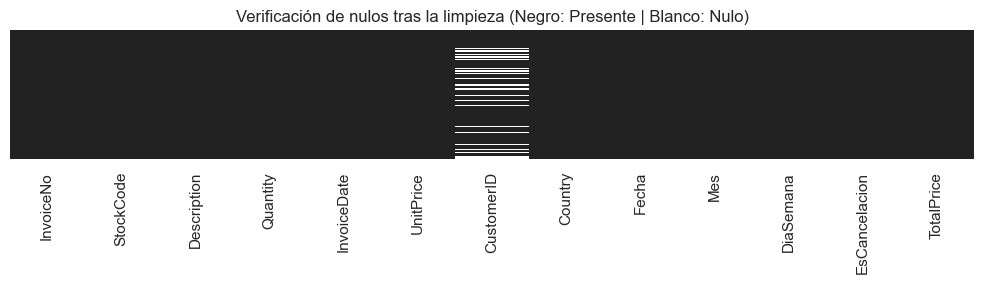

  Nulos restantes: {'CustomerID': 131516}


In [14]:

# 3.9.2 — Heatmap de nulos post-limpieza
plt.figure(figsize=(10, 3))
sns.heatmap(df_working.isnull(), yticklabels=False, cbar=False, cmap=['#222222', '#FFFFFF'])
plt.title('Verificación de nulos tras la limpieza (Negro: Presente | Blanco: Nulo)')
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}3.9.2_heatmap_nulos_clean.png', dpi=150)
plt.show()
print(f"  Nulos restantes: {df_working.isnull().sum()[df_working.isnull().sum() > 0].to_dict()}")


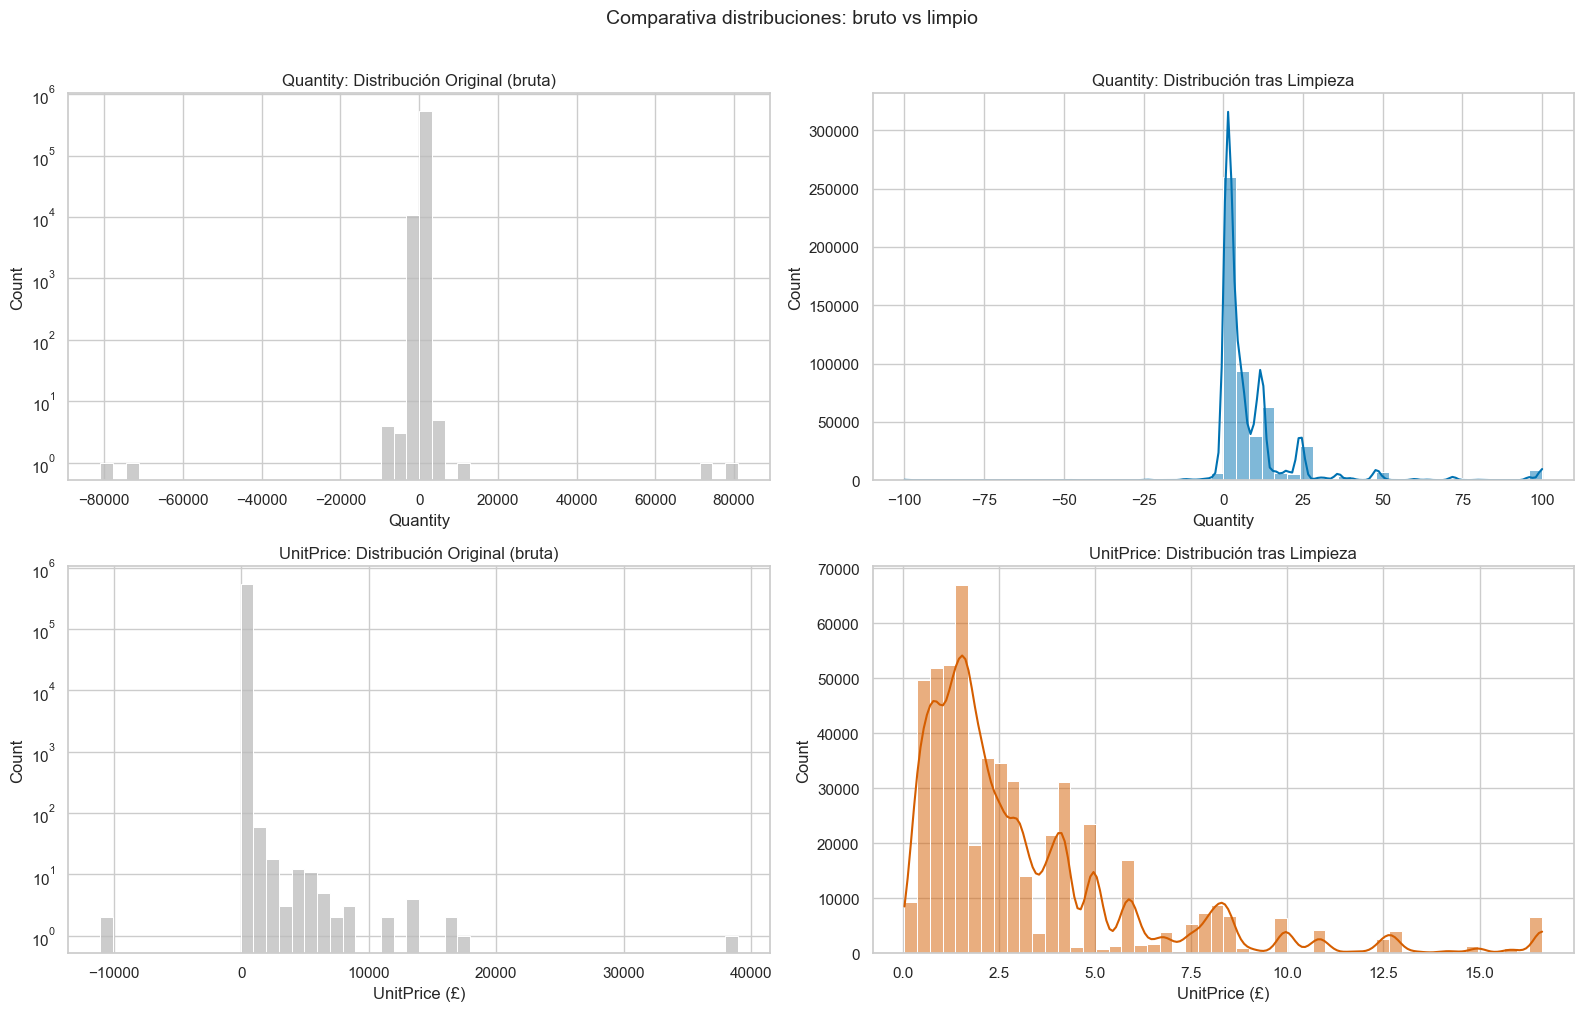

In [15]:

# 3.9.3 — Histogramas comparativos: distribución original vs limpia
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df_raw['Quantity'], bins=50, ax=ax[0,0], color='#BBBBBB', kde=False)
ax[0,0].set_title('Quantity: Distribución Original (bruta)')
ax[0,0].set_yscale('log')
ax[0,0].set_xlabel('Quantity')

sns.histplot(df_working['Quantity'], bins=50, ax=ax[0,1], color='#0072B2', kde=True)
ax[0,1].set_title('Quantity: Distribución tras Limpieza')
ax[0,1].set_xlabel('Quantity')

sns.histplot(df_raw['UnitPrice'], bins=50, ax=ax[1,0], color='#BBBBBB', kde=False)
ax[1,0].set_title('UnitPrice: Distribución Original (bruta)')
ax[1,0].set_yscale('log')
ax[1,0].set_xlabel('UnitPrice (£)')

sns.histplot(df_working['UnitPrice'], bins=50, ax=ax[1,1], color='#D55E00', kde=True)
ax[1,1].set_title('UnitPrice: Distribución tras Limpieza')
ax[1,1].set_xlabel('UnitPrice (£)')

plt.suptitle('Comparativa distribuciones: bruto vs limpio', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}3.9.3_histogramas_comparativa.png', dpi=150)
plt.show()


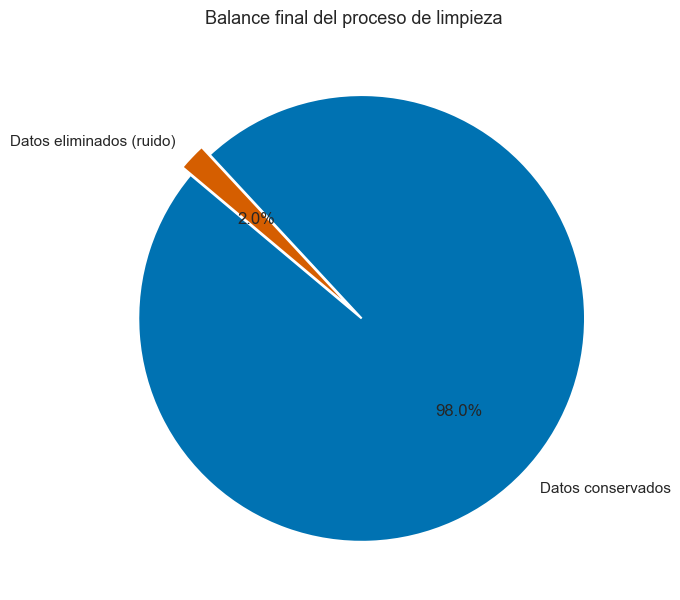

In [16]:

# 3.9.4 — Pie chart: balance datos conservados vs eliminados
labels  = ['Datos conservados', 'Datos eliminados (ruido)']
sizes   = [len(df_working), len(df_raw) - len(df_working)]
colores = ['#0072B2', '#D55E00']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colores, explode=(0.05, 0), wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Balance final del proceso de limpieza', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}3.9.4_balance_limpieza.png', dpi=150)
plt.show()


In [17]:
# 3.9.5 — Validación de la variable objetivo: ventas netas diarias
ventas_diarias_clean = df_working.groupby('Fecha')['TotalPrice'].sum()
dias_neg  = (ventas_diarias_clean < 0).sum()
dias_cero = (ventas_diarias_clean == 0).sum()

print(f"── 3.9.5 Validación variable objetivo — ventas netas diarias ──")
print(f"  Días con datos  : {len(ventas_diarias_clean)}")
print()
print(f"  Estadísticas:")
print(f"    Media   : £{ventas_diarias_clean.mean():>12,.2f}")
print(f"    Mediana : £{ventas_diarias_clean.median():>12,.2f}")
print(f"    Mínima  : £{ventas_diarias_clean.min():>12,.2f}")
print(f"    Máxima  : £{ventas_diarias_clean.max():>12,.2f}")
print()
print(f"  Días con ventas negativas (devoluciones > ventas): {dias_neg}  {'⚠ revisar' if dias_neg > 0 else '✓ ninguno'}")
print(f"  Días con ventas = 0                              : {dias_cero}  {'⚠ revisar' if dias_cero > 0 else '✓ ninguno'}")
print(f"\n  ✓ Variable objetivo lista para la sección de preprocesado")


── 3.9.5 Validación variable objetivo — ventas netas diarias ──
  Días con datos  : 305

  Estadísticas:
    Media   : £   28,605.66
    Mediana : £   25,943.31
    Mínima  : £    3,415.15
    Máxima  : £   83,931.62

  Días con ventas negativas (devoluciones > ventas): 0  ✓ ninguno
  Días con ventas = 0                              : 0  ✓ ninguno

  ✓ Variable objetivo lista para la sección de preprocesado


In [55]:
# 3.9.6 — Exportar CSV limpio
RUTA_EXPORT = f'{RUTA_INTERIM}data_sanitized.csv'
df_working.to_csv(RUTA_EXPORT, index=False, encoding='utf-8')

print(f"── 3.9.6 Exportación ──")
print(f"  Ruta        : {RUTA_EXPORT}")
print(f"  Filas       : {len(df_working):,}")
print(f"  Columnas    : {df_working.shape[1]} → {list(df_working.columns)}")
print(f"  Memoria (MB): {df_working.memory_usage(deep=True).sum() / 1024**2:.1f}")
print(f"\n  ✓ data_sanitized.csv listo para la sección de preprocesado")

── 3.9.6 Exportación ──
  Ruta        : ../../../data/interim/data_sanitized.csv
  Filas       : 531,172
  Columnas    : 13 → ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Fecha', 'Mes', 'DiaSemana', 'EsCancelacion', 'TotalPrice']
  Memoria (MB): 182.5

  ✓ data_sanitized.csv listo para la sección de preprocesado
